# <center>Imports and Globals</center>

In [24]:
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

PATH_CUBE = "Malin_1_Cube_Clean_Natural_spw0_v1.fits"

CHANNEL = 100   ## channel to plot
CMAP = "coolwarm" 
SPECTRAL, SPATIAL = 4, 9 ## Spectral and spatial convolution cube to plot

SPATIAL_MIN, SPATIAL_MAX = 1, 10  # spatial sigma range
SPECTRAL_MIN, SPECTAL_MAX = 1, 5    # spectral sigma range

#################################### Choose device for each library ########################################

import mlx.core as mx

device_mlx = mx.gpu # Mac Apple Silicon → Metal || Linux NVIDIA + mlx[cuda12/13] → CUDA
#device_mlx = mx.cpu 

import torch
import torch.nn.functional as F

device_torch = torch.device("cuda") # NVIDIDA
#device_torch = torch.device("mps") # Apple Metal
#device_torch = torch.device("xpu") # Intel GPU
#device_torch = torch.device("cpu") # NVIDIDA

In [8]:
with fits.open(PATH_CUBE, memmap=True) as hdul:
    cubo_np = hdul[0].data[0].astype(np.float32) 

# <center> Using MLX</center>

In [9]:
def gaussian_kernel_mlx(sigma_z, sigma_y, sigma_x, truncate=4.0, dtype=mx.float32):

    rz = int(truncate * sigma_z + 0.5)
    ry = int(truncate * sigma_y + 0.5)
    rx = int(truncate * sigma_x + 0.5)

    z = mx.arange(-rz, rz + 1, dtype=dtype)
    y = mx.arange(-ry, ry + 1, dtype=dtype)
    x = mx.arange(-rx, rx + 1, dtype=dtype)

    zz, yy, xx = mx.meshgrid(z, y, x, indexing="ij")

    kernel = mx.exp(
        -(
            zz**2 / (2 * sigma_z**2)
            + yy**2 / (2 * sigma_y**2)
            + xx**2 / (2 * sigma_x**2)
        )
    )
    kernel = kernel / kernel.sum()

    # MLX = (C_out, KD, KH, KW, C_in)
    kernel = mx.expand_dims(kernel, axis=0)   #  (1, KD, KH, KW)
    kernel = mx.expand_dims(kernel, axis=-1)  # (1, KD, KH, KW, 1)

    return kernel

In [10]:
cubo = mx.array(cubo_np)
cubo = mx.expand_dims(cubo, axis=0)   
cubo = mx.expand_dims(cubo, axis=-1)  

resultados = {}

for spatial in range(SPATIAL_MIN, SPATIAL_MAX):
    for spectral in range(SPECTRAL_MIN, SPECTAL_MAX): 
        kernel = gaussian_kernel_mlx(spectral, spatial, spatial)

        padding = (
            kernel.shape[1] // 2,  
            kernel.shape[2] // 2,  
            kernel.shape[3] // 2,  
        )

        res = mx.conv3d(cubo, kernel, padding=padding, stream=device_mlx)

        mx.eval(res)
        res_np = np.array(res)

        res_np = res_np[0, :, :, :, 0]

        resultados[(spectral, spatial)] = res_np

aux = resultados[(4, 9)]
print(aux.shape, aux.dtype)

(128, 216, 216) float32


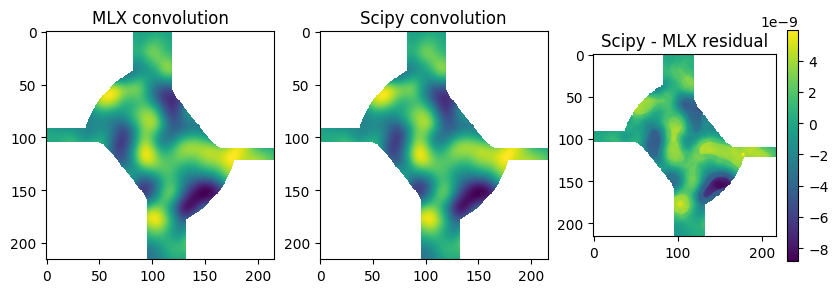

In [ ]:
fig, ax = plt.subplots(1,3, figsize = (10,6))
channel = CHANNEL
res_mlx = resultados[(SPECTRAL, SPATIAL)]

### Resultado libreria
ax[0].set_title(f"MLX convolution")
ax[0].imshow(res_mlx[channel])

### Resultado scipy
ax[1].set_title(f"Scipy convolution")
sci = gaussian_filter(cubo_np, sigma= [4,9,9], mode="constant", cval=0.0, truncate=4.0)
ax[1].imshow(sci[channel])

### Residuo
ax[2].set_title(f"Scipy - MLX residual")
pos = ax[2].imshow(sci[channel] - res_mlx[channel])
fig.colorbar(pos, ax=ax[2],  shrink=0.5)
plt.show()

# <center> Using PyTorch</center>

In [12]:
def gaussian_kernel_torch(sigma_z, sigma_y, sigma_x, truncate= 4.0, dtype =torch.float32):
    rz = int(truncate * sigma_z + 0.5)
    ry = int(truncate * sigma_y + 0.5)
    rx = int(truncate * sigma_x + 0.5)

    z = torch.arange( -rz, rz + 1, dtype=dtype)
    y = torch.arange( -ry, ry + 1, dtype=dtype)
    x = torch.arange( -rx, rx + 1, dtype=dtype)

    zz, yy, xx = torch.meshgrid(z, y, x, indexing="ij")

    kernel = torch.exp(
        -(zz**2 / (2* sigma_z**2)
          + yy**2 / (2 *sigma_y**2)
          + xx**2 / (2 * sigma_x**2))
    )
    kernel /= kernel.sum()
    kernel = kernel.unsqueeze(0).unsqueeze(0)
    
    return kernel

In [13]:
cubo =  torch.from_numpy(cubo_np).unsqueeze(0).unsqueeze(0).to(device_torch)

resultados = {}
with torch.no_grad(): ### no construir un grafico de ML
    for spatial in range(SPATIAL_MIN, SPATIAL_MAX):
        for spectral in range(SPECTRAL_MIN, SPECTAL_MAX): 
            kernel = gaussian_kernel_torch(spectral, spatial, spatial)
            kernel = kernel.to(device_torch)

            padding = (
                kernel.shape[-3]//2,
                kernel.shape[-2]//2,
                kernel.shape[-1]//2
            )
            res = F.conv3d(cubo, kernel, padding=padding)
            res = res.squeeze(0).squeeze(0).cpu().numpy()
            resultados[(spectral, spatial)] = res

aux = resultados[(4, 9)]
print(aux.shape, aux.dtype)

(128, 216, 216) float32


NameError: name 'SPECTRAL' is not defined

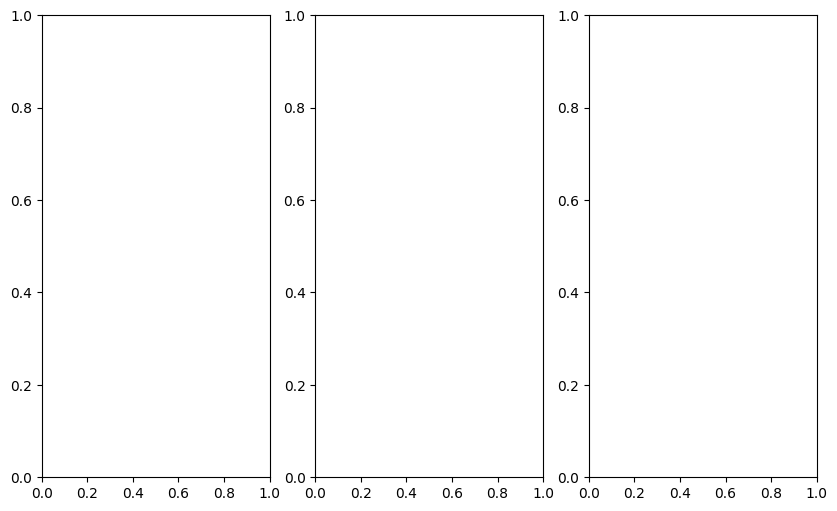

In [ ]:
fig, ax = plt.subplots(1,3, figsize = (10,6))
channel = CHANNEL
res_pytorch = resultados[(SPECTRAL, SPATIAL)]

### Resultado libreria
ax[0].set_title(f"Pytorch convolution")
ax[0].imshow(res_pytorch[channel])

### Resultado scipy
ax[1].set_title(f"Scipy convolution")
sci = gaussian_filter(cubo_np, sigma= [4,9,9], mode="constant", cval=0.0, truncate=4.0)
ax[1].imshow(sci[channel])

### Residuo

ax[2].set_title(f"Scipy - Pytorch residual")
pos = ax[2].imshow(sci[channel] - res_pytorch[channel])
fig.colorbar(pos, ax=ax[2],  shrink=0.5)
plt.show()

# <center>Comparison</center>